In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install -q efficientnet-pytorch grad-cam pytorch-ignite

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.7 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report)
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:",device)

Using: cuda


In [18]:
class Config:
    DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/'
    import glob
    all_image_dirs = glob.glob(os.path.join(DATA_DIR, "images_*/images"))
    
    all_images = []
    for img_dir in all_image_dirs:
        all_images.extend(glob.glob(os.path.join(img_dir, "*.png")))
    
    if all_images:
        IMG_DIR = os.path.dirname(all_images[0])
        print(f"Found {len(all_images)} images in {len(all_image_dirs)} directories")
        print(f"Using images from: {IMG_DIR}")
    else:
        IMG_DIR = None
    CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
    TRAIN_LIST = os.path.join(DATA_DIR, 'train_val_list.txt')
    TEST_LIST = os.path.join(DATA_DIR, 'test_list.txt')
    BBOX_PATH = os.path.join(DATA_DIR, 'BBox_List_2017.csv')
    
    IMG_SIZE = 256
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 1e-3
    NUM_CLASSES = 14

    NUM_WORKERS = 4
    PIN_MEMORY = True
    GRADIENT_ACCUMULATION_STEPS = 1
    
    # Disease names in order
    DISEASES = [
        'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 
        'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 
        'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 
        'Pleural_Thickening', 'Hernia'
    ]
    
    PATIENCE = 7
    
config = Config()

Found 112120 images in 12 directories
Using images from: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images


In [19]:
df = pd.read_csv(config.CSV_PATH)
print(f"Total images: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

def analyze_labels(df, diseases):
    label_lists = df['Finding Labels'].str.split('|')
    all_labels = [label for sublist in label_lists for label in sublist]
    
    print("="*50)
    print("LABEL DISTRIBUTION")
    print("="*50)
    
    distributions = {}
    for disease in diseases:
        count = (df['Finding Labels'].str.contains(disease, na=False)).sum()
        distributions[disease] = count
        print(f"{disease:20s}: {count:6d} ({count/len(df)*100:.2f}%)")
    
    num_labels_per_image = [len(labels) for labels in label_lists]
    print(f"\n{'='*50}")
    print("MULTI-LABEL STATISTICS")
    print(f"Average diseases per image: {np.mean(num_labels_per_image):.2f}")
    print(f"Max diseases in one image: {max(num_labels_per_image)}")
    print(f"Images with no finding: {(df['Finding Labels'] == 'No Finding').sum()}")
    
    return distributions

distributions = analyze_labels(df, config.DISEASES)

Total images: 112120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First few rows:
LABEL DISTRIBUTION
Atelectasis         :  11559 (10.31%)
Cardiomegaly        :   2776 (2.48%)
Effusion            :  13317 (11.88%)
Infiltration        :  19894 (17.74%)
Mass                :   5782 (5.16%)
Nodule              :   6331 (5.65%)
Pneumonia           :   1431 (1.28%)
Pneumothorax        :   5302 (4.73%)
Consolidation       :   4667 (4.16%)
Edema               :   2303 (2.05%)
Emphysema           :   2516 (2.24%)
Fibrosis            :   1686 (1.50%)
Pleural_Thickening  :   3385 (3.02%)
Hernia              :    227 (0.20%)

MULTI-LABEL STATISTICS
Average diseases per image: 1.26
Max diseases in one image: 9
Images with no finding: 60361


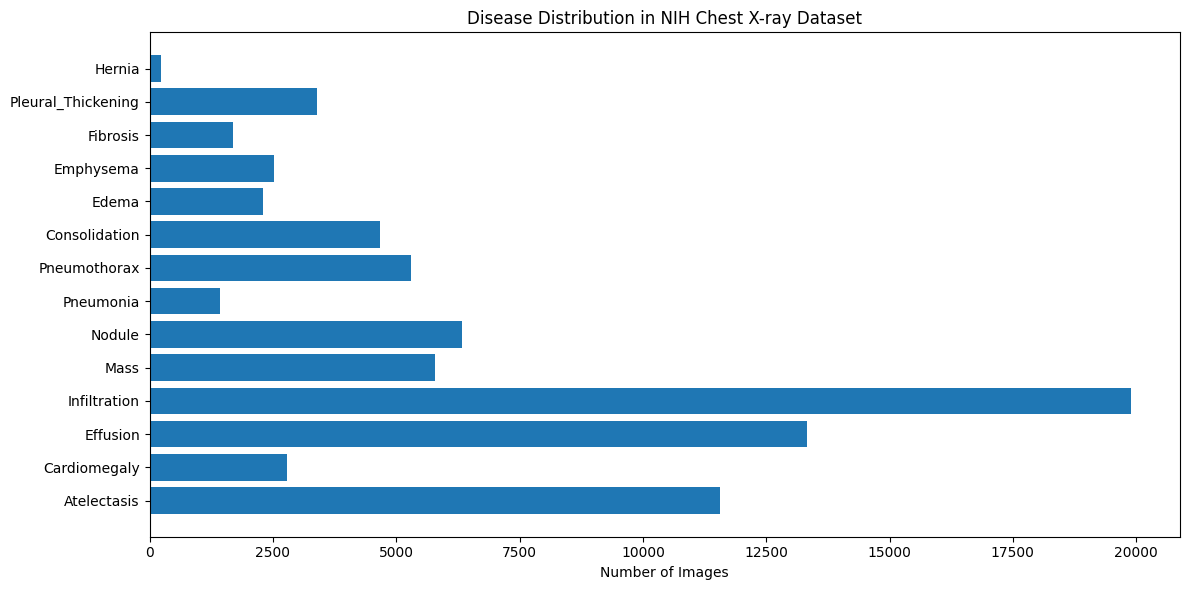

In [20]:
plt.figure(figsize=(12, 6))
disease_counts = [distributions[d] for d in config.DISEASES]
plt.barh(config.DISEASES, disease_counts)
plt.xlabel('Number of Images')
plt.title('Disease Distribution in NIH Chest X-ray Dataset')
plt.tight_layout()
plt.show()

In [21]:
class ChestXrayDataset(Dataset):
    def __init__(self, data_dir, csv_path, split_file, diseases, transform=None, is_train=True):
        self.data_dir = data_dir
        self.diseases = diseases
        self.transform = transform
        self.is_train = is_train
  
        import glob
        self.image_dirs = sorted(glob.glob(os.path.join(data_dir, "images_*/images")))
        print(f"Found {len(self.image_dirs)} image directories: {[os.path.basename(d) for d in self.image_dirs]}")
        
        self.df = pd.read_csv(csv_path)
        
        if os.path.exists(split_file):
            with open(split_file, 'r') as f:
                split_images = [line.strip() for line in f.readlines()]
            self.df = self.df[self.df['Image Index'].isin(split_images)].reset_index(drop=True)
        
        if is_train:
            self.df = self.df[self.df['Finding Labels'] != 'No Finding']
        
        print(f"{'Train' if is_train else 'Val/Test'} set: {len(self.df)} images")
    
    def __len__(self):
        return len(self.df)
    
    def _get_multilabel(self, labels_str):
        labels = [1 if disease in labels_str else 0 for disease in self.diseases]
        return torch.FloatTensor(labels)
    
    def _find_image_path(self, img_name):
        for img_dir in self.image_dirs:
            img_path = os.path.join(img_dir, img_name)
            if os.path.exists(img_path):
                return img_path
        return None
    
    def __getitem__(self, idx):
        # Load image
        img_name = self.df.iloc[idx]['Image Index']
        img_path = self._find_image_path(img_name)
        
        if img_path is None:
            print(f"ERROR: Image not found: {img_name}")
            print(f"Searched in: {self.image_dirs}")
            raise FileNotFoundError(f"Image {img_name} not found in any directory")
        
        image = Image.open(img_path).convert('RGB')
        
        labels_str = self.df.iloc[idx]['Finding Labels']
        labels = self._get_multilabel(labels_str)
        
        if self.transform:
            image = self.transform(image)
        
        metadata = {
            'img_name': img_name,
            'patient_id': self.df.iloc[idx]['Patient ID'] if 'Patient ID' in self.df.columns else 'Unknown',
            'age': self.df.iloc[idx]['Patient Age'] if 'Patient Age' in self.df.columns else 0,
            'gender': self.df.iloc[idx]['Patient Gender'] if 'Patient Gender' in self.df.columns else 'Unknown'
        }
        
        return image, labels, metadata

In [22]:
train_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [23]:
train_dataset = ChestXrayDataset(
    config.DATA_DIR,
    config.CSV_PATH, 
    config.TRAIN_LIST,
    config.DISEASES, 
    transform=train_transform, 
    is_train=True
)

val_dataset = ChestXrayDataset(
    config.DATA_DIR,
    config.CSV_PATH, 
    config.TEST_LIST,
    config.DISEASES, 
    transform=val_transform, 
    is_train=False
)
# Create data loaders
train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, 
    shuffle=True, num_workers=4, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

Found 12 image directories: ['images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images']
Train set: 36024 images
Found 12 image directories: ['images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images', 'images']
Val/Test set: 25596 images


In [24]:
import torchvision.models as models
import torch.nn as nn

class EfficientNetMultiLabel(nn.Module):
    def __init__(self, model_name='efficientnet_b1', num_classes=14, pretrained=True):
        super().__init__()

        if pretrained:
            self.backbone = models.efficientnet_b1(weights='DEFAULT')
        else:
            self.backbone = models.efficientnet_b1(weights=None)

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

In [25]:
def compute_class_weights(train_dataset, diseases):
    df = train_dataset.df
    
    label_matrix = np.zeros((len(df), len(diseases)))
    
    for i, disease in enumerate(diseases):
        label_matrix[:, i] = df['Finding Labels'].str.contains(disease, na=False).astype(int)
    
    pos_counts = label_matrix.sum(axis=0)
    neg_counts = len(df) - pos_counts
    
    pos_weight = neg_counts / (pos_counts + 1e-6)
    pos_weight = torch.FloatTensor(pos_weight).to(device)
    
    print("\nClass Weights (pos_weight):")
    for disease, weight in zip(diseases, pos_weight.cpu()):
        print(f"{disease:20s}: {weight:.4f}")
    
    return pos_weight

In [26]:
model = EfficientNetMultiLabel(model_name='efficientnet_b1',num_classes=config.NUM_CLASSES,pretrained=True)
model = model.to(device)

pos_weight = compute_class_weights(train_dataset, config.DISEASES).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler()

print(f"\nModel total parameters: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 234MB/s]



Class Weights (pos_weight):
Atelectasis         : 3.3507
Cardiomegaly        : 20.1037
Effusion            : 3.1603
Infiltration        : 1.6138
Mass                : 7.9301
Nodule              : 6.6517
Pneumonia           : 40.1233
Pneumothorax        : 12.6610
Consolidation       : 11.6311
Edema               : 25.1422
Emphysema           : 24.3155
Fibrosis            : 27.7962
Pleural_Thickening  : 15.0678
Hernia              : 254.4894

Model total parameters: 6,531,118


In [27]:
class MetricsTracker:
    def __init__(self, diseases):
        self.diseases = diseases
        self.reset()
    
    def reset(self):
        self.all_labels = []
        self.all_preds = []
        self.all_logits = []
        self.losses = []
    
    def update(self, logits, labels, loss):
        self.all_logits.extend(logits.cpu().detach().numpy())
        self.all_labels.extend(labels.cpu().numpy())
        self.losses.append(loss)
    
    def compute_metrics(self):
        y_true = np.array(self.all_labels)
        y_logits = np.array(self.all_logits)
        y_pred = (torch.sigmoid(torch.FloatTensor(y_logits)).numpy() >= 0.5).astype(int)
        y_proba = torch.sigmoid(torch.FloatTensor(y_logits)).numpy()
        
        auc_scores = []
        for i in range(len(self.diseases)):
            if len(np.unique(y_true[:, i])) > 1:
                auc = roc_auc_score(y_true[:, i], y_proba[:, i])
                auc_scores.append(auc)
            else:
                auc_scores.append(0.0)
        
        f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
        
        macro_auc = np.mean(auc_scores)
        macro_f1 = np.mean(f1_scores)
        
        accuracies = accuracy_score(y_true, y_pred, normalize=False)
        per_class_acc = []
        for i in range(len(self.diseases)):
            acc = accuracy_score(y_true[:, i], y_pred[:, i])
            per_class_acc.append(acc)
        
        metrics = {
            'auc_per_class': auc_scores,
            'f1_per_class': f1_scores,
            'accuracy_per_class': per_class_acc,
            'macro_auc': macro_auc,
            'macro_f1': macro_f1,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'avg_loss': np.mean(self.losses)
        }
        
        return metrics

In [28]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    tracker = MetricsTracker(config.DISEASES)
    
    pbar = tqdm(loader, desc='Training')
    optimizer.zero_grad()
    
    for batch_idx, (images, labels, _) in enumerate(pbar):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()

            if (batch_idx + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            
            if (batch_idx + 1) % config.GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()
        
        tracker.update(logits, labels, loss.item())
        pbar.set_postfix({'loss': loss.item(), 'lr': optimizer.param_groups[0]['lr']})
    
    return tracker.compute_metrics()

In [29]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    tracker = MetricsTracker(config.DISEASES)
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for images, labels, _ in pbar:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            logits = model(images)
            loss = criterion(logits, labels)
            
            tracker.update(logits, labels, loss.item())
            pbar.set_postfix({'loss': loss.item()})
    
    return tracker.compute_metrics()

In [30]:
def print_metrics(metrics, phase, diseases):
    print(f"\n{'='*60}")
    print(f"{phase} RESULTS")
    print(f"{'='*60}")
    print(f"Average Loss: {metrics['avg_loss']:.4f}")
    print(f"Macro AUC-ROC: {metrics['macro_auc']:.4f}")
    print(f"Macro F1 Score: {metrics['macro_f1']:.4f}")
    
    print(f"\n{'Disease':<22} {'AUC':<8} {'F1':<8} {'Acc':<8}")
    print("-"*50)
    for i, disease in enumerate(diseases):
        print(f"{disease:<22} {metrics['auc_per_class'][i]:.4f}   "
              f"{metrics['f1_per_class'][i]:.4f}   "
              f"{metrics['accuracy_per_class'][i]:.4f}")
    print(f"{'='*60}\n")

In [31]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_auc': [], 'val_auc': [],
    'train_f1': [], 'val_f1': []
}

best_val_auc = 0.0
patience_counter = 0

for epoch in range(config.EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{config.EPOCHS}")
    print(f"{'='*60}")
    
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)

    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    scheduler.step(val_metrics['macro_auc'])
    
    history['train_loss'].append(train_metrics['avg_loss'])
    history['val_loss'].append(val_metrics['avg_loss'])
    history['train_auc'].append(train_metrics['macro_auc'])
    history['val_auc'].append(val_metrics['macro_auc'])
    history['train_f1'].append(train_metrics['macro_f1'])
    history['val_f1'].append(val_metrics['macro_f1'])

    print_metrics(train_metrics, "TRAINING", config.DISEASES)
    print_metrics(val_metrics, "VALIDATION", config.DISEASES)
    
    if val_metrics['macro_auc'] > best_val_auc:
        best_val_auc = val_metrics['macro_auc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_metrics['macro_auc'],
            'val_f1': val_metrics['macro_f1'],
        }, 'efficient_net-b1_model.pth')
        print(f"New best model saved! (AUC: {best_val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= config.PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break


EPOCH 1/15


Validation: 100%|██████████| 400/400 [03:50<00:00,  1.73it/s, loss=0.474]



TRAINING RESULTS
Average Loss: 1.0939
Macro AUC-ROC: 0.7100
Macro F1 Score: 0.2403

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.6959   0.4514   0.6402
Cardiomegaly           0.7874   0.1868   0.7058
Effusion               0.7525   0.5154   0.6900
Infiltration           0.6260   0.5250   0.5940
Mass                   0.6588   0.2588   0.6064
Nodule                 0.6655   0.2924   0.5859
Pneumonia              0.5702   0.0563   0.5799
Pneumothorax           0.7351   0.2353   0.6884
Consolidation          0.6640   0.2067   0.6044
Edema                  0.8106   0.1699   0.7087
Emphysema              0.7944   0.1712   0.7347
Fibrosis               0.7231   0.1122   0.5918
Pleural_Thickening     0.6586   0.1632   0.5999
Hernia                 0.7977   0.0191   0.7150


VALIDATION RESULTS
Average Loss: 0.9371
Macro AUC-ROC: 0.7594
Macro F1 Score: 0.2186

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:50<00:00,  1.74it/s, loss=0.506]



TRAINING RESULTS
Average Loss: 1.0017
Macro AUC-ROC: 0.7638
Macro F1 Score: 0.2773

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.7376   0.4881   0.6723
Cardiomegaly           0.8698   0.2667   0.7965
Effusion               0.7978   0.5647   0.7349
Infiltration           0.6636   0.5525   0.6240
Mass                   0.7376   0.3265   0.7062
Nodule                 0.7046   0.3210   0.6402
Pneumonia              0.6349   0.0681   0.6208
Pneumothorax           0.7871   0.2803   0.7391
Consolidation          0.6860   0.2194   0.6299
Edema                  0.8448   0.1974   0.7512
Emphysema              0.8781   0.2540   0.8231
Fibrosis               0.7659   0.1299   0.6591
Pleural_Thickening     0.7017   0.1831   0.6393
Hernia                 0.8844   0.0311   0.7958


VALIDATION RESULTS
Average Loss: 0.9267
Macro AUC-ROC: 0.7709
Macro F1 Score: 0.2228

Disease                AUC      F1       Acc     
----

...


TRAINING RESULTS
Average Loss: 0.6640
Macro AUC-ROC: 0.8845
Macro F1 Score: 0.4108

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.8073   0.5553   0.7342
Cardiomegaly           0.9704   0.4800   0.9039
Effusion               0.8623   0.6368   0.7874
Infiltration           0.7290   0.6033   0.6721
Mass                   0.8738   0.4702   0.8035
Nodule                 0.8069   0.4108   0.7339
Pneumonia              0.9227   0.1903   0.8200
Pneumothorax           0.9280   0.4567   0.8498
Consolidation          0.7677   0.2622   0.6825
Edema                  0.9500   0.3382   0.8626
Emphysema              0.9756   0.4694   0.9163
Fibrosis               0.9292   0.2670   0.8302
Pleural_Thickening     0.8614   0.3034   0.7708
Hernia                 0.9989   0.3079   0.9827


VALIDATION RESULTS
Average Loss: 1.0196
Macro AUC-ROC: 0.7875
Macro F1 Score: 0.2832

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:51<00:00,  1.72it/s, loss=0.348]



TRAINING RESULTS
Average Loss: 0.6085
Macro AUC-ROC: 0.8974
Macro F1 Score: 0.4491

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.8142   0.5625   0.7408
Cardiomegaly           0.9764   0.5136   0.9153
Effusion               0.8660   0.6441   0.7921
Infiltration           0.7355   0.6085   0.6783
Mass                   0.8896   0.4927   0.8158
Nodule                 0.8188   0.4263   0.7462
Pneumonia              0.9508   0.2428   0.8634
Pneumothorax           0.9455   0.5014   0.8699
Consolidation          0.7915   0.2869   0.7102
Edema                  0.9629   0.3876   0.8867
Emphysema              0.9809   0.5064   0.9268
Fibrosis               0.9499   0.3122   0.8611
Pleural_Thickening     0.8815   0.3206   0.7818
Hernia                 0.9996   0.4821   0.9916


VALIDATION RESULTS
Average Loss: 1.0475
Macro AUC-ROC: 0.7894
Macro F1 Score: 0.2859

Disease                AUC      F1       Acc     
----

Validation: 100%|██████████| 400/400 [03:52<00:00,  1.72it/s, loss=0.312]



TRAINING RESULTS
Average Loss: 0.5598
Macro AUC-ROC: 0.9081
Macro F1 Score: 0.4886

Disease                AUC      F1       Acc     
--------------------------------------------------
Atelectasis            0.8203   0.5710   0.7452
Cardiomegaly           0.9831   0.5658   0.9301
Effusion               0.8711   0.6490   0.7947
Infiltration           0.7406   0.6116   0.6803
Mass                   0.9036   0.5133   0.8274
Nodule                 0.8349   0.4389   0.7527
Pneumonia              0.9658   0.2879   0.8892
Pneumothorax           0.9574   0.5392   0.8854
Consolidation          0.8100   0.2998   0.7213
Edema                  0.9743   0.4358   0.9049
Emphysema              0.9862   0.5683   0.9417
Fibrosis               0.9620   0.3522   0.8812
Pleural_Thickening     0.9040   0.3570   0.8073
Hernia                 0.9999   0.6513   0.9958


VALIDATION RESULTS
Average Loss: 1.1935
Macro AUC-ROC: 0.7848
Macro F1 Score: 0.3003

Disease                AUC      F1       Acc     
----

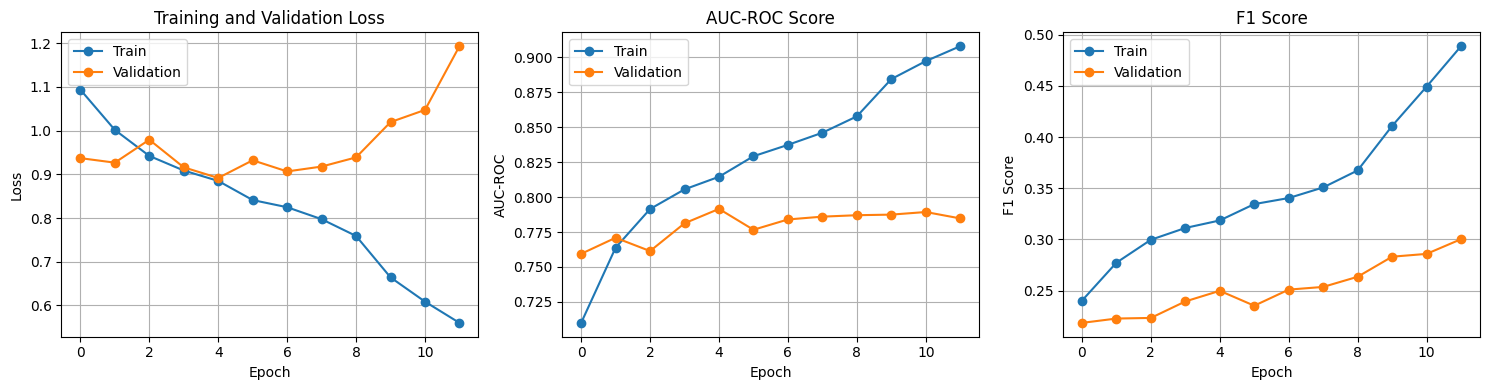

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'], label='Validation', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_auc'], label='Train', marker='o')
axes[1].plot(history['val_auc'], label='Validation', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC Score')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history['train_f1'], label='Train', marker='o')
axes[2].plot(history['val_f1'], label='Validation', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# torch.serialization.add_safe_globals([np.dtypes.Float64DType])
checkpoint = torch.load('./efficient_net-b1_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with validation AUC: {checkpoint['val_auc']:.4f}")

test_metrics = validate_epoch(model, val_loader, criterion, device)
print_metrics(test_metrics, "FINAL TEST SET", config.DISEASES)

Loaded best model from epoch 5 with validation AUC: 0.7916


Validation:  38%|███▊      | 152/400 [01:27<01:33,  2.66it/s, loss=0.928]

In [ ]:
def plot_confusion_matrices(y_true, y_pred, diseases, save_path=None):
    n_diseases = len(diseases)
    n_cols = 4
    n_rows = (n_diseases + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten()
    
    for i, disease in enumerate(diseases):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                   xticklabels=['Negative', 'Positive'],
                   yticklabels=['Negative', 'Positive'])
        axes[i].set_title(f'{disease}\n(TP={cm[1,1]}, FP={cm[0,1]}, FN={cm[1,0]})')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Confusion Matrices for All Diseases', fontsize=16, y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(test_metrics['y_true'], test_metrics['y_pred'], config.DISEASES, 'confusion_matrices.png')

In [ ]:
def plot_classification_report(y_true, y_pred, diseases):
    report_data = []
    for i, disease in enumerate(diseases):
        tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred[:, i]).ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        report_data.append({
            'Disease': disease,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'F1-Score': f1
        })
    
    report_df = pd.DataFrame(report_data)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(report_df.set_index('Disease'), annot=True, fmt='.3f', cmap='RdYlGn', 
                cbar_kws={'label': 'Score'}, ax=ax, vmin=0, vmax=1)
    ax.set_title('Classification Report - Per Disease Metrics', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
    
    return report_df

report_df = plot_classification_report(test_metrics['y_true'], test_metrics['y_pred'], config.DISEASES)
print("\nClassification Report:")
print(report_df.to_string(index=False))

In [73]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class GradCAMVisualizer:
    
    def __init__(self, model, target_layers, device):
        self.model = model
        self.device = device
        self.cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    
    def visualize(self, image_tensor, metadata, disease_idx, threshold=0.5):
        self.model.eval()
        
        with torch.no_grad():
            logits = self.model(image_tensor.unsqueeze(0).to(self.device))
            probs = torch.sigmoid(logits).cpu().numpy()[0]
        
        disease_name = config.DISEASES[disease_idx]
        is_predicted = probs[disease_idx] >= threshold

        img_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)
        
        targets = [ClassifierOutputTarget(disease_idx)]
        
        grayscale_cam = self.cam(input_tensor=image_tensor.unsqueeze(0).to(self.device),targets=targets)[0]
        
        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(img_np)
        axes[0].set_title(f'Original X-ray\n{metadata["img_name"]}')
        axes[0].axis('off')
        
        axes[1].imshow(img_np)
        axes[1].imshow(grayscale_cam, cmap='jet', alpha=0.5)
        axes[1].set_title(f'Grad-CAM++: {disease_name}\nPrediction: {is_predicted} (Prob: {probs[disease_idx]:.3f})')
        axes[1].axis('off')
        
        axes[2].imshow(visualization)
        axes[2].set_title(f'Overlay Visualization')
        axes[2].axis('off')
        
        plt.suptitle(f'Patient: {metadata["patient_id"]}, Age: {metadata["age"]}, Gender: {metadata["gender"]}')
        plt.tight_layout()
        plt.show()
        
        return visualization, probs[disease_idx]


GRAD-CAM++ VISUALIZATION EXAMPLES

--- Example 1: 00000003_000.png ---
Ground truth: ['Hernia']


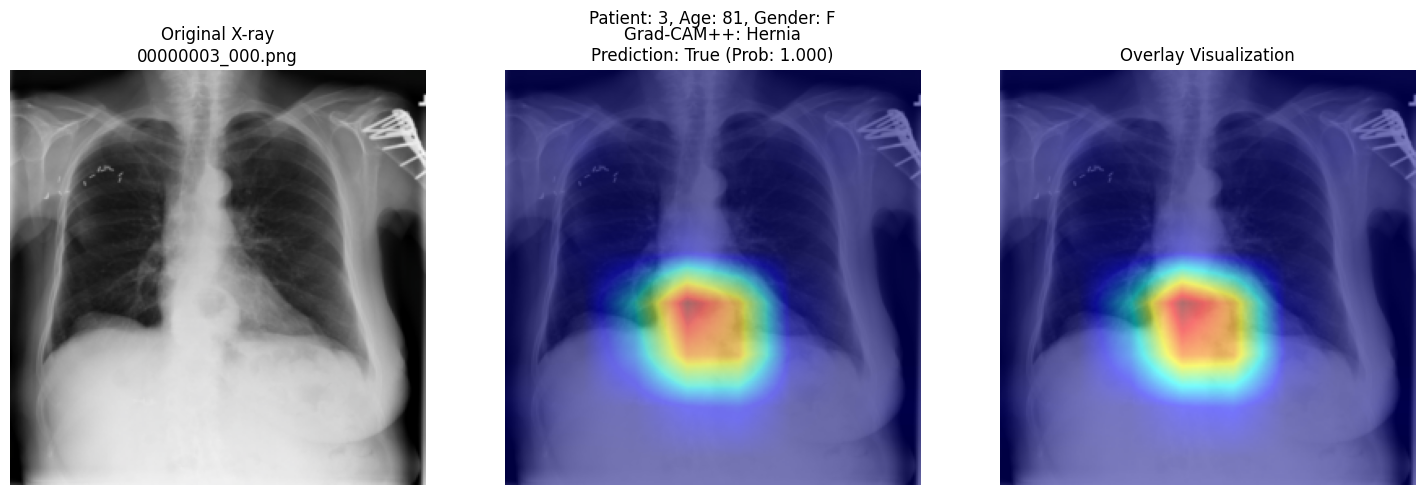


--- Example 2: 00000003_001.png ---
Ground truth: ['Hernia']


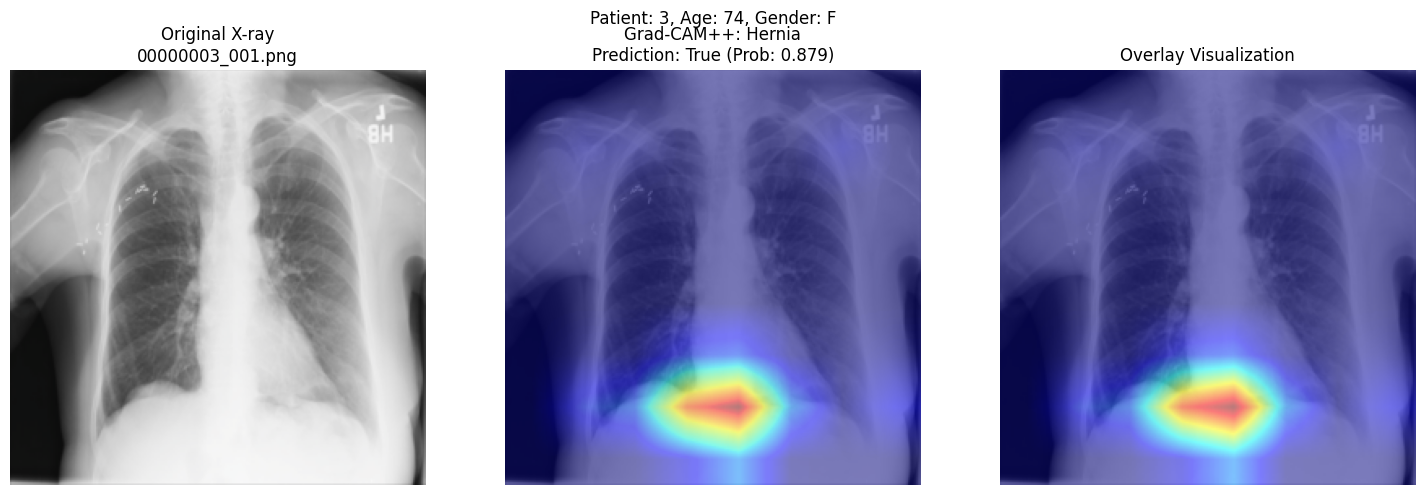


--- Example 3: 00000003_002.png ---
Ground truth: ['Hernia']


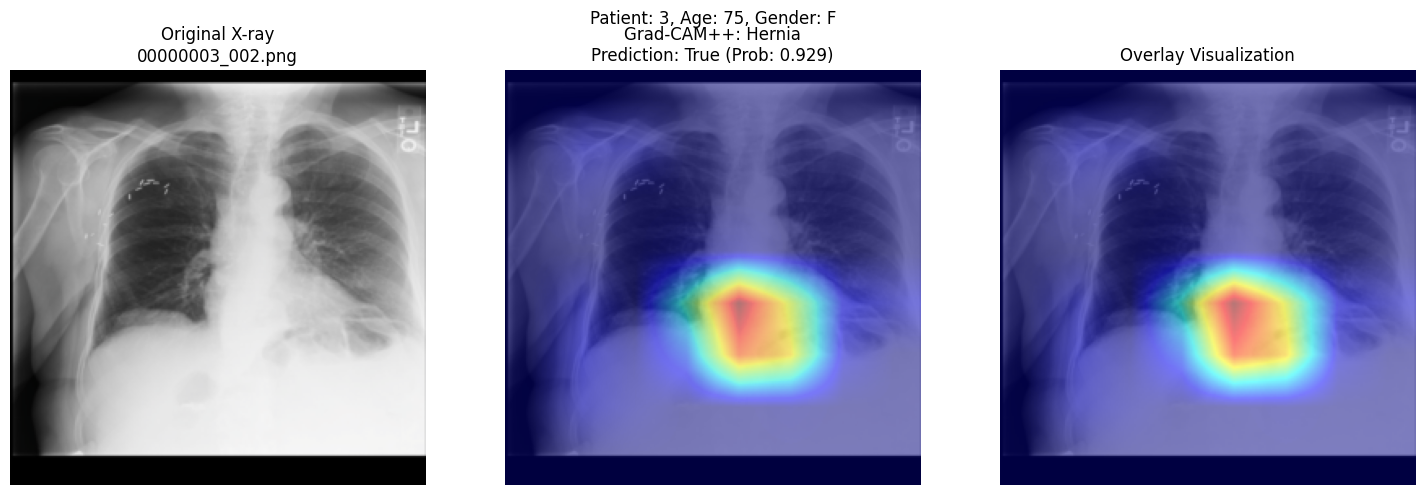


--- Example 4: 00000003_003.png ---
Ground truth: ['Infiltration', 'Hernia']


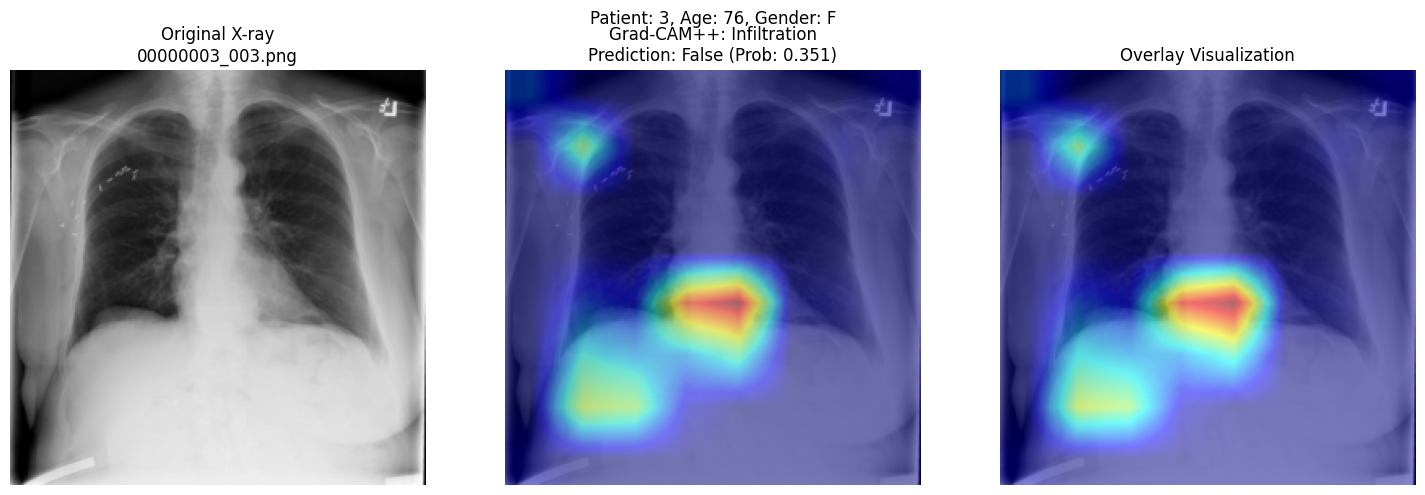


--- Example 5: 00000003_004.png ---
Ground truth: ['Hernia']


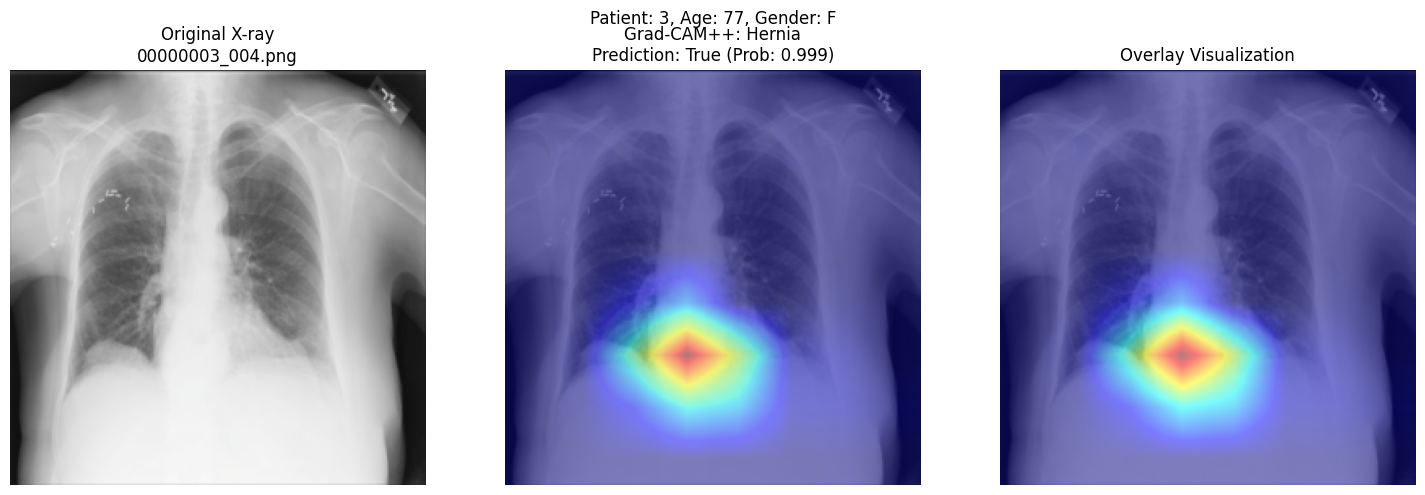

In [74]:
target_layers = [model.backbone.features[-1]]

visualizer = GradCAMVisualizer(model, target_layers, device)

print("\n" + "="*60)
print("GRAD-CAM++ VISUALIZATION EXAMPLES")
print("="*60)

num_examples = 15
diseases_to_visualize = [0, 1, 3, 6, 7]  # Atelectasis, Cardiomegaly, Infiltration, Pneumonia, Pneumothorax

for idx in range(min(num_examples, len(val_dataset))):
    image, labels, metadata = val_dataset[idx]
    
    present_diseases = [i for i, label in enumerate(labels) if label == 1]
    
    if present_diseases:
        disease_idx = present_diseases[0]
        print(f"\n--- Example {idx+1}: {metadata['img_name']} ---")
        print(f"Ground truth: {[config.DISEASES[i] for i in present_diseases]}")
        
        try:
            vis, prob = visualizer.visualize(image, metadata, disease_idx)
        except Exception as e:
            print(f"Could not generate Grad-CAM++: {e}")

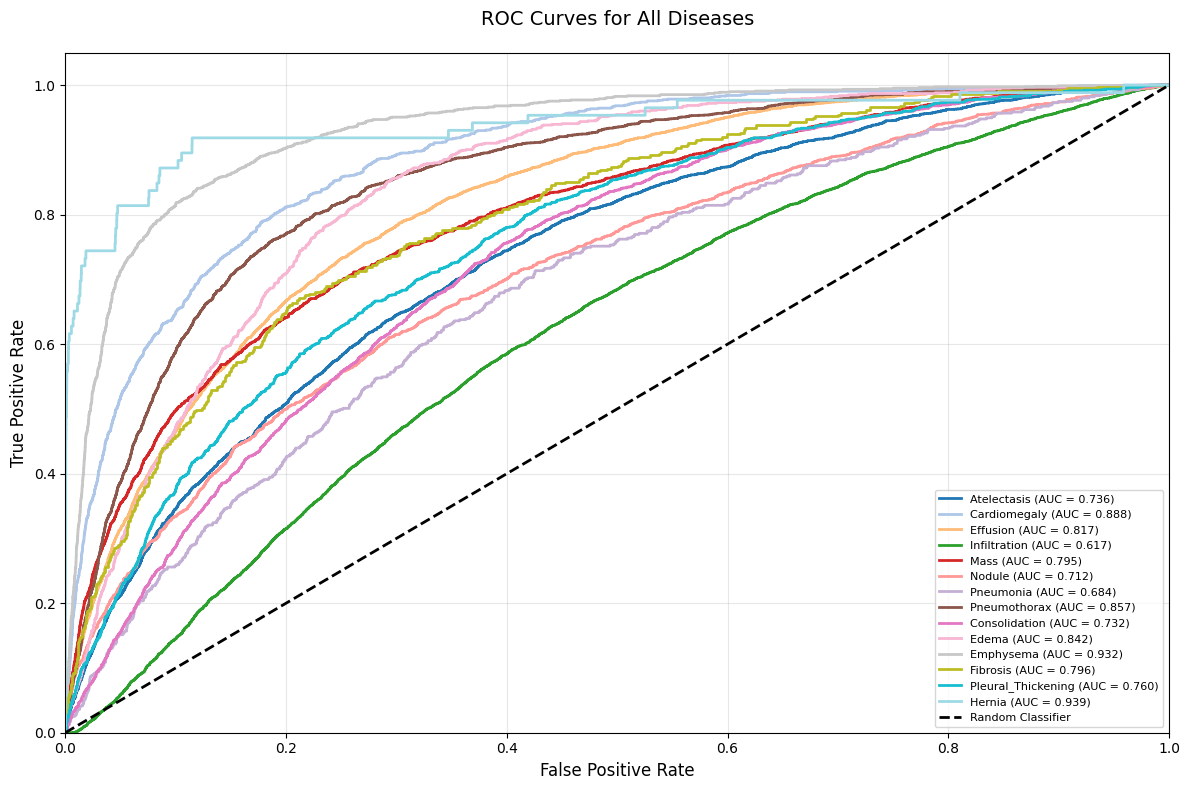

In [66]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(y_true, y_proba, diseases):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(diseases)))
    
    for i, (disease, color) in enumerate(zip(diseases, colors)):
        if len(np.unique(y_true[:, i])) > 1:
            fpr, tpr, _ = roc_curve(y_true[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2,
                   label=f'{disease} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curves for All Diseases', fontsize=14, pad=20)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_roc_curves(test_metrics['y_true'], test_metrics['y_proba'], config.DISEASES)

In [67]:
def generate_summary_report(metrics, diseases, history, save_path='results_summary.txt'):
    
    with open(save_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write("NIH CHEST X-RAY MULTI-LABEL CLASSIFICATION RESULTS\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Model: EfficientNet-B1\n")
        f.write(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}\n")
        f.write(f"Batch Size: {config.BATCH_SIZE}\n")
        f.write(f"Learning Rate: {config.LEARNING_RATE}\n\n")
        
        f.write("FINAL METRICS\n")
        f.write("-"*40 + "\n")
        f.write(f"Macro AUC-ROC: {metrics['macro_auc']:.4f}\n")
        f.write(f"Macro F1 Score: {metrics['macro_f1']:.4f}\n")
        f.write(f"Average Loss: {metrics['avg_loss']:.4f}\n\n")
        
        f.write("PER-CLASS METRICS\n")
        f.write("-"*40 + "\n")
        f.write(f"{'Disease':<22} {'AUC':<8} {'F1':<8} {'Accuracy':<8}\n")
        f.write("-"*50 + "\n")
        
        for i, disease in enumerate(diseases):
            f.write(f"{disease:<22} {metrics['auc_per_class'][i]:.4f}   "
                   f"{metrics['f1_per_class'][i]:.4f}   "
                   f"{metrics['accuracy_per_class'][i]:.4f}\n")
        
        f.write("\nTRAINING HISTORY\n")
        f.write("-"*40 + "\n")
        f.write(f"Best Validation AUC: {max(history['val_auc']):.4f}\n")
        f.write(f"Best Validation F1: {max(history['val_f1']):.4f}\n")
        f.write(f"Final Training AUC: {history['train_auc'][-1]:.4f}\n")
        f.write(f"Final Validation AUC: {history['val_auc'][-1]:.4f}\n")
        
    print(f"Summary report saved to {save_path}")

generate_summary_report(test_metrics, config.DISEASES, history)

Summary report saved to results_summary.txt


In [68]:
def predict_single_image(model, image_path, transform, device):
    model.eval()
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
    
    threshold = 0.5
    predictions = [(config.DISEASES[i], probs[i]) 
                   for i in range(len(config.DISEASES)) 
                   if probs[i] >= threshold]
    
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    return predictions, probs

In [70]:
def display_prediction(image_path, predictions, probs, save_path=None):
    image = Image.open(image_path).convert('RGB')
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    ax1.imshow(image, cmap='gray')
    ax1.set_title('Chest X-ray Image')
    ax1.axis('off')
    
    if predictions:
        diseases, scores = zip(*predictions)
        bars = ax2.barh(diseases, scores, color='skyblue')
        ax2.set_xlim(0, 1)
        ax2.set_xlabel('Probability')
        ax2.set_title('Disease Predictions')
        
        for bar, score in zip(bars, scores):
            if score >= 0.7:
                bar.set_color('green')
            elif score >= 0.5:
                bar.set_color('orange')
            else:
                bar.set_color('red')
    else:
        ax2.text(0.5, 0.5, 'No diseases detected\n(All probabilities < 0.5)',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Predictions')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()